<a href="https://colab.research.google.com/github/Sonali73724/Python/blob/main/Week5_SonaliSingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
artificial intelligence is transforming modern technology
deep learning is a powerful branch of machine learning
machine learning helps computers learn from experience
neural networks are inspired by the human brain
deep learning models require large amounts of data
artificial intelligence is used in healthcare education and finance
recurrent neural networks process sequential information
rnn models are useful for language modeling
lstm remembers long term dependencies in text
gru is a simplified version of lstm
lstm uses memory cells to preserve important information
gru uses update and reset gates for learning
text generation predicts the next word in a sentence
natural language processing enables computers to understand language
language models learn grammar and sentence structure
transformers have improved natural language processing significantly
deep learning algorithms improve with more training data
machine learning is widely used in recommendation systems
computer vision helps machines understand images
speech recognition converts spoken words into text
chatbots use artificial intelligence to answer questions
data preprocessing improves the quality of machine learning models
tokenization converts text into numerical sequences
embeddings represent words as dense vectors
training neural networks requires optimization algorithms
the adam optimizer is commonly used in deep learning
loss functions measure prediction errors during training
accuracy improves as the model learns meaningful patterns
text generation creates new sentences from learned knowledge
language models predict the next most probable word
students learn artificial intelligence through practical projects
deep learning applications include image classification and text generation
recurrent neural networks struggle with vanishing gradients
lstm solves the vanishing gradient problem effectively
gru provides similar performance with fewer parameters
deep learning models generate meaningful and coherent sentences
sequence models capture contextual information from text
natural language understanding is an important research area
python is a popular programming language for deep learning
tensorflow provides powerful tools for building neural networks
keras simplifies the implementation of deep learning models
text preprocessing includes cleaning tokenization and padding
padding ensures all sequences have equal length
embedding layers convert words into numerical representations
hidden layers learn complex relationships in the data
deep learning is transforming industries around the world
artificial intelligence improves decision making using data
students practice text generation using recurrent neural networks
lstm and gru perform better than vanilla rnn
language models can generate meaningful paragraphs
deep learning continues to evolve with new research
'''
print(corpus)


artificial intelligence is transforming modern technology
deep learning is a powerful branch of machine learning
machine learning helps computers learn from experience
neural networks are inspired by the human brain
deep learning models require large amounts of data
artificial intelligence is used in healthcare education and finance
recurrent neural networks process sequential information
rnn models are useful for language modeling
lstm remembers long term dependencies in text
gru is a simplified version of lstm
lstm uses memory cells to preserve important information
gru uses update and reset gates for learning
text generation predicts the next word in a sentence
natural language processing enables computers to understand language
language models learn grammar and sentence structure
transformers have improved natural language processing significantly
deep learning algorithms improve with more training data
machine learning is widely used in recommendation systems
computer vision help

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 204
X shape: (332, 8)
y shape: (332,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

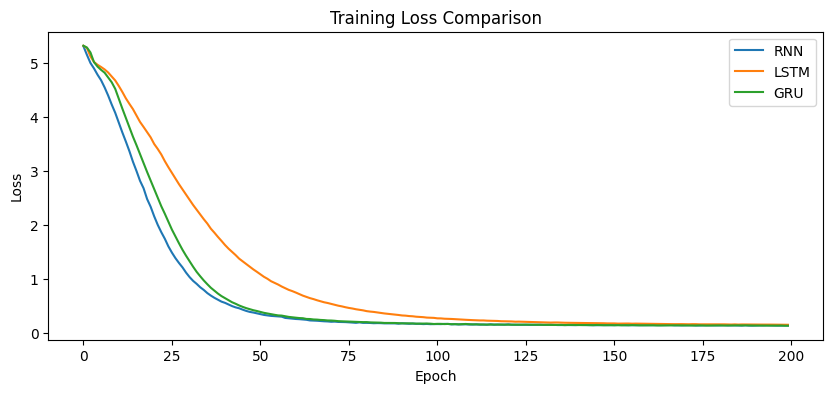

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is a powerful branch of machine learning models computers large
LSTM: deep learning models generate meaningful and coherent sentences sentences rnn rnn rnn
GRU : deep learning is a powerful branch of machine learning finance finance computers


#Final Conclusion

1.Three deep learning models (Vanilla RNN, LSTM, and GRU) were trained on the same text corpus for text generation.

The Vanilla RNN was able to learn basic sentence patterns but struggled to
maintain context in the later part of the generated sentence.

The LSTM model produced the most meaningful and coherent text because of its memory cell and gating mechanism. Although a few words were repeated, it generated the best overall sentence among the three models.

The GRU model also generated meaningful text and maintained context well. Its performance was close to LSTM, but it showed some word repetition towards the end of the generated sentence.

Overall, LSTM achieved the best text quality, GRU provided comparable performance with a simpler architecture, and Vanilla RNN showed the weakest performance in handling long-term dependencies.

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**